In [1]:
import os
import json
import pandas as pd

# Define the directory path where the files are stored
directory_path = '/allah/stuff/freq/project_1/user_data/backtest_results/'

# Define the file path for the latest backtest result index
last_result_file_path = os.path.join(directory_path, '.last_result.json')

# Load the index to find the name of the latest backtest result file
with open(last_result_file_path, 'r') as file:
    last_result_data = json.load(file)
    latest_backtest_filename = last_result_data['latest_backtest']

# Construct the full path to the latest backtest result file
latest_backtest_file_path = os.path.join(directory_path, latest_backtest_filename)

# Load the latest backtest result JSON file
with open(latest_backtest_file_path, 'r') as file:
    latest_backtest_data = json.load(file)

# Convert the relevant trade data into a DataFrame
trades_df = pd.DataFrame(latest_backtest_data['strategy']['TrendReversalLabelingStrategy']['trades'])

# Select and rename necessary columns from the DataFrame
filtered_df = trades_df[['pair', 'open_date', 'close_date', 'profit_ratio', 'is_short', 'stop_loss_ratio']]
filtered_df.rename(columns={'stop_loss_ratio': 'stop_loss'}, inplace=True)

# Define a function to categorize profitability
def determine_profitability(profit_ratio):
    if profit_ratio > 0:
        return 'WIN'
    elif profit_ratio < 0:
        return 'LOSE'
    else:
        return 'NEUTRAL'

# Apply the function to create a new 'profitability' column
filtered_df['profitability'] = filtered_df['profit_ratio'].apply(determine_profitability)

# Optionally, print the DataFrame to view its contents (commented out by default)
# print(filtered_df)


/tmp/ipykernel_1335903/2095445661.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df.rename(columns={'stop_loss_ratio': 'stop_loss'}, inplace=True)
/tmp/ipykernel_1335903/2095445661.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['profitability'] = filtered_df['profit_ratio'].apply(determine_profitability)


In [ ]:
cleaned_df

,pair,open_date,close_date,profit_ratio,is_short,stop_loss,profitability
0,ETH/USDT:USDT,2019-11-27 10:14:00+00:00,2019-11-27 10:40:00+00:00,0.081353,False,-0.003,WIN
31,ETH/USDT:USDT,2019-11-27 13:07:00+00:00,2019-11-27 13:13:00+00:00,0.000068,False,-0.003,WIN
37,ETH/USDT:USDT,2019-11-27 13:23:00+00:00,2019-11-27 13:34:00+00:00,0.000811,False,-0.003,WIN
40,ETH/USDT:USDT,2019-11-27 13:49:00+00:00,2019-11-27 13:56:00+00:00,0.000135,False,-0.003,WIN
54,ETH/USDT:USDT,2019-11-27 14:55:00+00:00,2019-11-27 15:25:00+00:00,0.004815,False,-0.003,WIN
...,...,...,...,...,...,...,...
356770,ETH/USDT:USDT,2025-01-19 05:36:00+00:00,2025-01-19 06:04:00+00:00,0.005440,False,-0.003,WIN
356794,ETH/USDT:USDT,2025-01-19 10:47:00+00:00,2025-01-19 10:51:00+00:00,0.000022,False,-0.003,WIN
356798,ETH/USDT:USDT,2025-01-19 11:19:00+00:00,2025-01-19 11:24:00+00:00,0.000655,False,-0.003,WIN
356806,ETH/USDT:USDT,2025-01-19 12:48:00+00:00,2025-01-19 12:56:00+00:00,0.002291,False,-0.003,WIN


/tmp/ipykernel_1335903/1055581936.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['open_date'] = pd.to_datetime(filtered_df['open_date'])
/tmp/ipykernel_1335903/1055581936.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['profit_ratio'] = pd.to_numeric(filtered_df['profit_ratio'], errors='coerce')
/tmp/ipykernel_1335903/1055581936.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_averages = cleaned_df.resample('

Monthly Averages of Profit Ratio (Positive Long Trades):
open_date
2019-11-30 00:00:00+00:00    0.003197
2019-12-31 00:00:00+00:00    0.002496
2020-01-31 00:00:00+00:00    0.002632
2020-02-29 00:00:00+00:00    0.002488
2020-03-31 00:00:00+00:00    0.002367
                               ...   
2024-09-30 00:00:00+00:00    0.002791
2024-10-31 00:00:00+00:00    0.002957
2024-11-30 00:00:00+00:00    0.002774
2024-12-31 00:00:00+00:00    0.002406
2025-01-31 00:00:00+00:00    0.002692
Freq: ME, Name: profit_ratio, Length: 63, dtype: float64


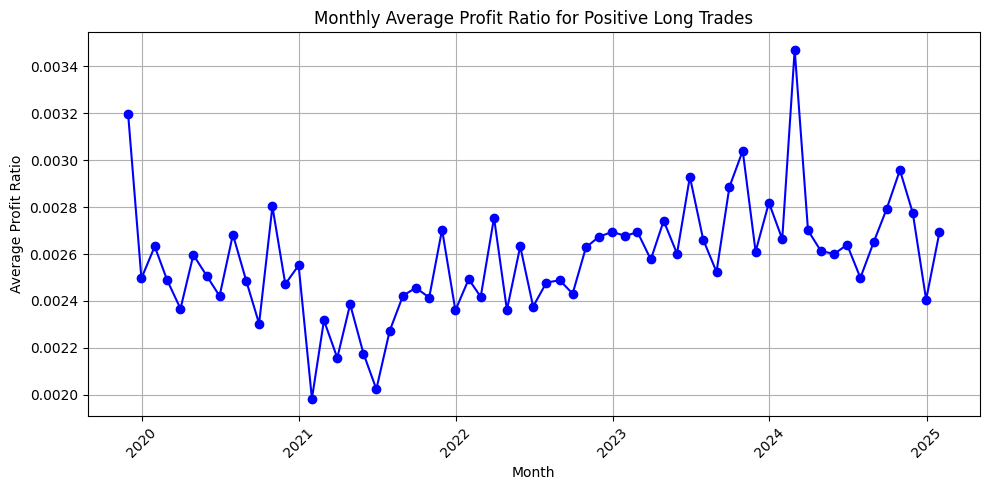

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert 'open_date' to datetime and 'profit_ratio' to numeric, handling non-convertible values
filtered_df['open_date'] = pd.to_datetime(filtered_df['open_date'])
filtered_df['profit_ratio'] = pd.to_numeric(filtered_df['profit_ratio'], errors='coerce')

# Filter for positive long trades and drop rows with NaN 'profit_ratio'
cleaned_df = filtered_df[(filtered_df['profit_ratio'] > 0) & (filtered_df['is_short'] == False)].dropna(subset=['profit_ratio'])

# Check for the presence of 'open_date' to proceed with resampling
if 'open_date' in cleaned_df.columns:
    # Resample, calculate monthly mean of 'profit_ratio', and plot
    monthly_averages = cleaned_df.resample('M', on='open_date')['profit_ratio'].mean()
    print("Monthly Averages of Profit Ratio (Positive Long Trades):")
    print(monthly_averages)

    plt.figure(figsize=(10, 5))
    plt.plot(monthly_averages.index, monthly_averages, marker='o', linestyle='-', color='blue')
    plt.title('Monthly Average Profit Ratio for Positive Long Trades')
    plt.xlabel('Month')
    plt.ylabel('Average Profit Ratio')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'open_date' column not found in DataFrame.")


In [9]:
profitability_stats = filtered_df['profitability'].value_counts()
print(profitability_stats)
filtered_df[filtered_df['profitability'] == 'NEUTRAL']

profitability
LOSE       232095
WIN        122595
NEUTRAL      2121
Name: count, dtype: int64


,pair,open_date,close_date,profit_ratio,is_short,stop_loss,profitability
6,ETH/USDT:USDT,2019-11-27 11:25:00+00:00,2019-11-27 11:25:00+00:00,0.0,False,-0.003,NEUTRAL
65,ETH/USDT:USDT,2019-11-27 17:11:00+00:00,2019-11-27 17:11:00+00:00,0.0,True,-0.003,NEUTRAL
71,ETH/USDT:USDT,2019-11-27 17:34:00+00:00,2019-11-27 17:34:00+00:00,0.0,True,-0.003,NEUTRAL
83,ETH/USDT:USDT,2019-11-27 18:11:00+00:00,2019-11-27 18:11:00+00:00,0.0,True,-0.003,NEUTRAL
102,ETH/USDT:USDT,2019-11-27 21:50:00+00:00,2019-11-27 21:50:00+00:00,0.0,False,-0.003,NEUTRAL
...,...,...,...,...,...,...,...
355611,ETH/USDT:USDT,2025-01-13 03:45:00+00:00,2025-01-13 03:45:00+00:00,0.0,True,-0.003,NEUTRAL
355667,ETH/USDT:USDT,2025-01-13 10:42:00+00:00,2025-01-13 10:42:00+00:00,0.0,True,-0.003,NEUTRAL
355678,ETH/USDT:USDT,2025-01-13 12:07:00+00:00,2025-01-13 12:07:00+00:00,0.0,False,-0.003,NEUTRAL
356247,ETH/USDT:USDT,2025-01-16 13:29:00+00:00,2025-01-16 13:29:00+00:00,0.0,True,-0.003,NEUTRAL
